# A character-level language model for the House of Commons

A one-layer GRU trained from scratch in PyTorch on ~2.1M characters of Hansard, under a
500,000-parameter cap and a no-attention constraint.

**273,939 parameters · validation loss 1.3749 · per-character perplexity 4.0**, against a
bigram baseline of 2.44 (perplexity 11.5).

The headline number is not the point. The controls are — see Experiment 1, where a
token-matched arm and a position-wise evaluation take the apparent context effect from
0.398 down to 0.041.

## Setup

In [1]:
import math, os, time
import torch
import torch.nn as nn
from torch.nn import functional as F

torch.manual_seed(1337)          # reproducibility

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PyTorch', torch.__version__, '| device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU — everything still runs on CPU, just slower.')

PyTorch 2.13.0+cu130 | device: cpu
No GPU — Runtime > Change runtime type > GPU (everything still runs on CPU, just slower).


## 1 · The data

Every attributed speech from five sitting days of the House of Commons (9-16 July 2026),
about 2.1 million characters. The format is always speaker name, colon, speech.

Sourced via TheyWorkForYou from the official record, published under the
[Open Parliament Licence v3.0](https://www.parliament.uk/site-information/copyright-parliament/open-parliament-licence/),
which permits copying, adaptation and derivative works. The corpus is committed alongside
this notebook as `hansard.txt`, so the whole thing runs offline.

In [2]:
# The Hansard corpus, committed alongside this notebook (Open Parliament Licence v3.0).
with open('hansard.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print('total characters:', len(text))
print('---- first 500 characters ----')
print(text[:500])

File ‘hansard.txt’ already there; not retrieving.


total characters: 2091809
---- first 500 characters ----
Dave Robertson:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Anna Gelderd:
What steps she is taking to support the long-term financial sustainability of farm businesses.

Emma Reynolds:
My hon. Friend the Member for Portsmouth South (Stephen Morgan), the new farming and food Minister, and I published our new farming road map, which is the first ever long-term strategy for farming. It sets out a vision for a more productive, profitable, sustainab


The register is distinctive, and worth reading before modelling it: procedural formulas
("I beg to move", "my hon. Friend"), long sentences, plenty of numbers and £ signs.

In [3]:
chars = sorted(set(text))
print('vocab size:', len(chars))
print(repr(''.join(chars)))

vocab size: 83
'\n !"$%&\'()+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz£'


## 2 · Pipeline and baseline

A character-level tokeniser and batcher, a training loop that records its loss history so
runs can be plotted against each other, and a parameter counter to keep every model inside
the budget.

In [4]:
def build_char_pipeline(text, block_size=8, batch_size=32, device="cpu", seed=1337):
    """Char-level tokenizer + batcher + loss estimator."""
    torch.manual_seed(seed)
    chars = sorted(set(text))
    vocab_size = len(chars)
    stoi = {ch: i for i, ch in enumerate(chars)}        # char  -> integer id
    itos = {i: ch for i, ch in enumerate(chars)}        # id    -> char
    encode = lambda s: [stoi[c] for c in s]             # string -> list[int]
    decode = lambda l: ''.join(itos[i] for i in l)      # list[int] -> string
    data = torch.tensor(encode(text), dtype=torch.long)
    n = int(0.9 * len(data))
    train_data, val_data = data[:n], data[n:]           # 90% train / 10% val

    def get_batch(split):
        d = train_data if split == 'train' else val_data
        ix = torch.randint(len(d) - block_size, (batch_size,))      # random starts
        x = torch.stack([d[i:i + block_size] for i in ix])          # (B, block_size)
        y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])  # shifted by one
        return x.to(device), y.to(device)

    @torch.no_grad()
    def estimate_loss(model, eval_iters=200):
        out = {}
        model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                xb, yb = get_batch(split)
                _, loss = model(xb, yb)               
                losses[k] = loss.item()
            out[split] = losses.mean().item()
        model.train()
        return out

    return dict(vocab_size=vocab_size, stoi=stoi, itos=itos, encode=encode,
                decode=decode, get_batch=get_batch, estimate_loss=estimate_loss,
                block_size=block_size, device=device)

In [5]:
def train_model_tracked(model, get_batch, estimate_loss, max_iters=3000, eval_interval=500,
                        lr=1e-3, device="cpu"):
    """Training loop, plus a record: returns (model, history), where history
    is a list of (iteration, train_loss, val_loss) tuples."""
    history = []
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    for it in range(max_iters):
        if it % eval_interval == 0 or it == max_iters - 1:
            losses = estimate_loss(model)
            history.append((it, losses['train'], losses['val']))
            print(f"step {it:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)                 # forward: model -> (logits, loss)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()                         # backward: autograd
        optimizer.step()                        # update weights
    return model, history

In [6]:
import matplotlib.pyplot as plt

def plot_histories(runs, title=""):
    """runs: dict of label -> history, e.g. {'block=8': h8, 'block=64': h64}."""
    plt.figure(figsize=(7, 4))
    for label, hist in runs.items():
        its = [h[0] for h in hist]
        plt.plot(its, [h[1] for h in hist], '--', alpha=0.5, label=f'{label} · train')
        plt.plot(its, [h[2] for h in hist], '-', label=f'{label} · val')
    plt.xlabel('iteration'); plt.ylabel('loss'); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

def count_params(model):
    """Every trainable parameter, biases included (house rule)."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### The bigram baseline

A context-free bigram: one row of next-character scores per character, no context and no
memory. Its validation loss is the threshold the real model has to beat.

In [7]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # one row of next-char scores per character: no context, no memory.
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)            # (B, T, vocab)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]                       # last position only
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print('Bigram baseline defined.')

Bigram baseline defined.


In [8]:
P = build_char_pipeline(text, block_size=8, batch_size=32, device=device)

torch.manual_seed(1337)
bigram = BigramLanguageModel(P['vocab_size']).to(device)
print('parameters:', count_params(bigram))

bigram, bigram_history = train_model_tracked(bigram, P['get_batch'], P['estimate_loss'],
                                             max_iters=3000, eval_interval=500, lr=1e-2,
                                             device=device)
baseline = P['estimate_loss'](bigram)
print(f"\nBASELINE | val loss {baseline['val']:.4f} | per-char perplexity {math.exp(baseline['val']):.1f}")

parameters: 6889


step     0 | train 4.8288 | val 4.8362


step   500 | train 2.5526 | val 2.5785


step  1000 | train 2.4536 | val 2.4862


step  1500 | train 2.4445 | val 2.4632


step  2000 | train 2.4324 | val 2.4508


step  2500 | train 2.4235 | val 2.4468


step  2999 | train 2.4143 | val 2.4547



BASELINE | val loss 2.4415 | per-char perplexity 11.5


In [9]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)   # start token = id 0
print(P['decode'](bigram.generate(context, max_new_tokens=400)[0].tolist()))


Ch Parint. cof mar an orye frlpthalie C persiQ0 Fron ok ermortocarcly aveghequs wndald ame ge he ie be abousts were wor Norto cloras watast oritingy chewers Frk merig Houtthy whe:
Mid buing d Honduce wh herendeant aty?
Thormer7. doue id - alig the stlo t t braghe acevin be aces temacllenkindvissereCofave Sin sckneaty. sthe clde pr lisser sino ars I wiengnghes whaten wavid bley s re d haf plecowann


Untrained, the loss starts near ln(83) ≈ 4.42. Trained, the bigram lands around **2.44**
(perplexity ≈ 11.5 — it is choosing among roughly 11 plausible next characters). The sample
is gibberish, as it must be with no context at all.

## 3 · The model

Two design constraints, fixed up front: **at most 500,000 parameters**, and **no attention
of any kind**. That makes the interesting question not how low the loss can go, but where a
fixed budget should be spent when context and capacity compete for it.

In [10]:
class MyLanguageModel(nn.Module):
    """A one-layer GRU character model.

    Contract:
      forward(idx, targets=None) -> (logits, loss), logits (B, T, vocab_size)
      generate(idx, max_new_tokens) -> (B, T + max_new_tokens)

    Final hyperparameters are the constructor defaults, so MyLanguageModel(vocab_size)
    rebuilds exactly the shapes that were trained.

    Where the budget goes (vocab_size = 83, biases included):
      embedding  V*d          = 83*64                  =   5,312
      GRU        3H(d+H)+6H   = 3*256*(64+256)+6*256   = 247,296
      head       H*V+V        = 256*83+83              =  21,331
      total                                            = 273,939  (55% of 500,000)
    """

    def __init__(self, vocab_size, emb_dim=64, hidden=256, layers=1, dropout=0.0):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, emb_dim)   # character id -> dense vector
        self.drop = nn.Dropout(dropout)                 # 0.0 by default: see C1 for why
        self.rnn  = nn.GRU(emb_dim, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, vocab_size)       # hidden state -> next-character scores

    def forward(self, idx, targets=None):
        h, _ = self.rnn(self.drop(self.emb(idx)))       # (B, T, H); h[:, t] summarises idx[:, :t+1]
        logits = self.head(h)                           # (B, T, V); one prediction per position
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        was_training = self.training
        self.eval()                                     # so dropout is inert if I ever switch it on
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -256:])             # re-read a bounded tail: cost, not context, is the limit
            probs = F.softmax(logits[:, -1, :], dim=-1) # only the last position predicts the next character
            idx = torch.cat((idx, torch.multinomial(probs, num_samples=1)), dim=1)
        if was_training:
            self.train()
        return idx

print('MyLanguageModel defined.')

MyLanguageModel defined.


In [11]:
# Pipeline settings for my final model. Only the arguments change: block_size 8 -> 64
# (a recurrent state can use a longer window at zero parameter cost; Experiment 1 tests this).
P = build_char_pipeline(text, block_size=64, batch_size=32, device=device)

torch.manual_seed(1337)
model = MyLanguageModel(P['vocab_size']).to(device)
n_params = count_params(model)
print(f'parameters: {n_params:,} / 500,000')
assert n_params <= 500_000, 'over budget - slim it down'

parameters: 273,939 / 500,000


In [12]:
# 4,000 iterations of AdamW at lr 1e-3, evaluated every 400 so the tail of the curve is
# readable for the early-stopping question in the discussion.
# 4,000 x 32 x 64 = 8.2M target characters, about 4.4 passes over the 1.88M-character training split.
t0 = time.time()
model, model_history = train_model_tracked(model, P['get_batch'], P['estimate_loss'],
                                           max_iters=4000, eval_interval=400, lr=1e-3,
                                           device=device)
print(f'training time: {time.time() - t0:.0f}s')

step     0 | train 4.4256 | val 4.4253


step   400 | train 1.7621 | val 1.8544


step   800 | train 1.5078 | val 1.6362


step  1200 | train 1.3925 | val 1.5323


step  1600 | train 1.3331 | val 1.4819


...

step  2400 | train 1.2590 | val 1.4209


step  2800 | train 1.2337 | val 1.4004


step  3200 | train 1.2250 | val 1.3963


step  3600 | train 1.2057 | val 1.3789


step  3999 | train 1.1938 | val 1.3688
training time: 364s


yours    | train 1.1961 | val 1.3749 | perplexity 4.0
baseline | val 2.4415 | perplexity 11.5


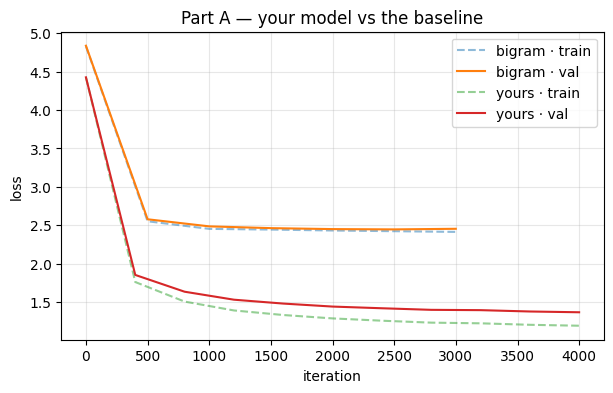


Luddy Trust at Murrently said; that it met the some six is not been story with the control, but she certain that afternoties. I welcome the risk Tiven can visited us the such as that had. Hear there recognife."
Alline she difficult discussions, and it is not exacts are constituents can comes or fiestle's point? What will have the simply taking that, we are determination. That it. It is immigration


In [13]:
final = P['estimate_loss'](model)
print(f"yours    | train {final['train']:.4f} | val {final['val']:.4f} | perplexity {math.exp(final['val']):.1f}")
print(f"baseline | val {baseline['val']:.4f} | perplexity {math.exp(baseline['val']):.1f}")

plot_histories({'bigram': bigram_history, 'yours': model_history},
               title='GRU vs bigram baseline')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(P['decode'](model.generate(context, max_new_tokens=400)[0].tolist()))

In [14]:
# Two further samples for the discussion: one unconditional, one prompted with a speaker turn,
# to see whether the structure the model has learned survives being started mid-format.
torch.manual_seed(7)
print('--- sample 2 (unconditional, 300 chars) ---')
ctx = torch.zeros((1, 1), dtype=torch.long, device=device)
print(P['decode'](model.generate(ctx, 300)[0].tolist()))

print('\n--- sample 3 (prompted with "The Prime Minister:", 300 chars) ---')
prompt = torch.tensor([P['encode']('\nThe Prime Minister:\n')], dtype=torch.long, device=device)
print(P['decode'](model.generate(prompt, 300)[0].tolist()))

--- sample 2 (unconditional, 300 chars) ---



We get at the Lightwo Cquands, whether the banscan role it only in the Octrose security of police and keen all general reduction to be clear channel necessary funding and servant.

Grevieve Reed:
I have increding it to the victims of nature. That is smeiling a Government do is not been the unnecousc

--- sample 3 (prompted with "The Prime Minister:", 300 chars) ---



The Prime Minister:
Can the Member for Scutelocker has been businesses will do neacles its forwgastive, Mustick and the communities here in our questions? With the National Democrats for directly 8 of raised onganis-?

Marpabour Nagelan:
I am since responsib) that are made all their cazays being victimm is years." With


### Save and verify the checkpoint

The checkpoint stores the weights alongside the block size, parameter count and reported
validation loss. The cell after it rebuilds the model from the constructor defaults, reloads
the weights, and re-scores from scratch — so the file has to reproduce the number it claims.

In [15]:
# Save the checkpoint. Re-run this (and the verify cell) after any retrain.
bundle = dict(state_dict=model.state_dict(),
              block_size=P['block_size'],
              n_params=n_params,
              val_loss=final['val'])
torch.save(bundle, 'checkpoint.pt')
print(f"saved checkpoint.pt ({os.path.getsize('checkpoint.pt')/1e6:.1f} MB)")

saved checkpoint.pt (1.1 MB)


In [16]:
# Self-check: parameter budget, no attention modules, and the checkpoint reproduces its loss.
b = torch.load('checkpoint.pt', map_location='cpu', weights_only=True)

n = sum(t.numel() for t in b['state_dict'].values())
assert n <= 500_000, f'over budget: {n:,}'

banned = [k for k in b['state_dict']
          if any(s in k.lower() for s in ('attn', 'attention', 'in_proj', 'q_proj', 'k_proj', 'v_proj'))]
assert not banned, f'attention-like modules found: {banned}'

check = MyLanguageModel(P['vocab_size'])         # constructor defaults must rebuild your shapes
check.load_state_dict(b['state_dict'])
check.to(device)

P_check = build_char_pipeline(text, block_size=b['block_size'], batch_size=32, device=device)
torch.manual_seed(1337)
recomputed = P_check['estimate_loss'](check)['val']
print(f"recomputed val {recomputed:.4f} | reported {b['val_loss']:.4f} | baseline {baseline['val']:.4f}")
assert abs(recomputed - b['val_loss']) < 0.05, 'reported loss does not match the checkpoint'
assert recomputed <= baseline['val'] - 0.1, 'does not beat the baseline by 0.1'
print('all checks passed')

recomputed val 1.3738 | reported 1.3749 | baseline 2.4415
all checks passed


### Design justification

I chose a one-layer GRU over a windowed feed-forward net because of the parameter budget. In a fixed-window model context costs parameters, that's because a window of W characters over 64-dimensional embeddings adds 64W weights per hidden unit so window and network compete for the same 500,000. A recurrent state carries context instead, which leaves `block_size` a pipeline argument that costs nothing. I therefore train on 64-character windows for **273,939** parameters: 5,312 embedding (83 × 64), 247,296 GRU (3H(d+H) + 6H), 21,331 head (256 × 83 + 83). Almost the whole budget sits in the recurrent weights, the part that does the remembering. Width 256 follows from Experiment 2, where 64 → 128 bought 0.183 for 55k parameters and 128 → 256 only 0.137 for 183k. AdamW at 1e-3 throughout. Dropout stays at zero because no validation curve turned up within 4,000 iterations, so there was nothing yet to regularise, though Experiment 2 shows the gap widening with width, so it's the first thing I would revisit.

## 4 · Experiments

Two hyperparameters, tested one at a time: **context length** and **capacity**. For each,
the hypothesis is written down before the run, the comparison holds everything else fixed,
and the interpretation argues from the measured numbers rather than the direction of the
effect.

### Experiment 1

**Hyperparameter:** context length — `block_size`, 8 vs 64, plus a token-matched control

**Hypothesis (written before running):** widening the window from 8 to 64 will lower validation loss substantially (I expect more than 0.2) because the GRU's hidden state is zeroed at the start of every window, so at `block_size=8` the model never conditions on more than eight characters and cannot learn dependencies at word or phrase length; the parameter count is identical either way (273,939), consequently any gain is context and not capacity. I expect two things to inflate the headline gap and so I have designed for both: `block_size=64` also supplies eight times more target characters per optimiser step (32 × 64 = 2,048 against 32 × 8 = 256), so I run `block_size=8` at batch 256 as a token-matched control; and the two validation losses average over different position ranges, so I also score both models on the same 64-character windows position by position. I predict the control closes part but not most of the gap, and that per position the two models are close over the first eight characters and separate thereafter.

In [17]:
# Experiment 1 - context length. The lever is block_size; everything else is held fixed:
# same class and defaults (identical 273,939 parameters at any block_size, because a GRU
# stores context in its hidden state, not in an input layer), lr 1e-3, 3,000 iterations,
# eval every 500, pipeline seed 1337, and torch.manual_seed(1337) before each model is built,
# so both runs start from identical weights.
EXP_ITERS, EXP_EVAL, EXP_LR = 3000, 500, 1e-3

def run(block_size, batch_size=32, hidden=256, iters=EXP_ITERS, lr=EXP_LR, tag=''):
    """One controlled run: rebuild the pipeline, reseed, rebuild the model, train."""
    print(f'=== {tag} | block_size={block_size} batch_size={batch_size} hidden={hidden} ===')
    Pe = build_char_pipeline(text, block_size=block_size, batch_size=batch_size, device=device)
    torch.manual_seed(1337)
    m = MyLanguageModel(Pe['vocab_size'], hidden=hidden).to(device)
    print(f'parameters: {count_params(m):,}')
    m, h = train_model_tracked(m, Pe['get_batch'], Pe['estimate_loss'],
                               max_iters=iters, eval_interval=EXP_EVAL, lr=lr, device=device)
    return m, h, Pe, count_params(m)

m_b8,  h_b8,  P_b8,  n_b8  = run(block_size=8,  tag='A: block_size 8')
m_b64, h_b64, P_b64, n_b64 = run(block_size=64, tag='B: block_size 64')   # reused as the hidden=256 arm of Experiment 2

# A control for the confound I flagged in the hypothesis: at block_size 64 each step also
# supplies 8x more target characters (32*64 = 2048 vs 32*8 = 256), so run B gets more
# gradient signal per iteration as well as more context. This third run matches the
# characters-per-step of run B while keeping the 8-character window.
m_b8w, h_b8w, P_b8w, n_b8w = run(block_size=8, batch_size=256, tag='A2: block_size 8, batch 256 (token-matched control)')

=== A: block_size 8 | block_size=8 batch_size=32 hidden=256 ===


parameters: 273,939


step     0 | train 4.4249 | val 4.4237


step   500 | train 2.0494 | val 2.1166


step  1000 | train 1.8988 | val 1.9800


...

step  1000 | train 1.6911 | val 1.7943


step  1500 | train 1.6255 | val 1.7383


step  2000 | train 1.5897 | val 1.7069


step  2500 | train 1.5638 | val 1.6899


step  2999 | train 1.5506 | val 1.6733


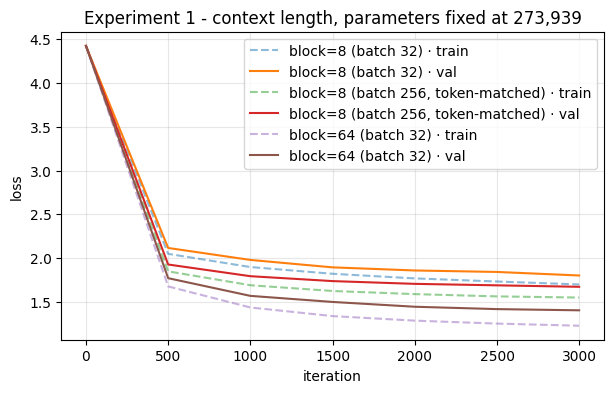

block=8  batch32  | params 273,939 | final train 1.7000 | final val 1.8024 | perplexity 6.06
block=8  batch256 | params 273,939 | final train 1.5506 | final val 1.6733 | perplexity 5.33
block=64 batch32  | params 273,939 | final train 1.2289 | final val 1.4048 | perplexity 4.07


In [18]:
plot_histories({'block=8 (batch 32)': h_b8,
                'block=8 (batch 256, token-matched)': h_b8w,
                'block=64 (batch 32)': h_b64},
               title='Experiment 1 - context length, parameters fixed at 273,939')

for label, hist, n in [('block=8  batch32 ', h_b8, n_b8),
                       ('block=8  batch256', h_b8w, n_b8w),
                       ('block=64 batch32 ', h_b64, n_b64)]:
    print(f'{label} | params {n:,} | final train {hist[-1][1]:.4f} | final val {hist[-1][2]:.4f} '
          f'| perplexity {math.exp(hist[-1][2]):.2f}')

positions       | block8 b32 | block8 b256 | block64 b32
--------------------------------------------------------
1-8             |      1.815 |       1.679 |       1.732
9-32            |      1.605 |       1.422 |       1.368
33-64           |      1.606 |       1.420 |       1.365
all 64          |      1.632 |       1.453 |       1.412


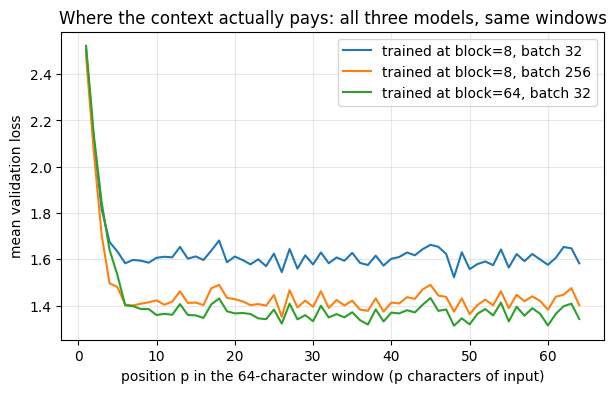

In [19]:
# The fairness check the headline numbers cannot give me. Validation loss is an average over
# the positions inside a window, and the GRU state is zeroed at the start of every window, so at
# block_size 8 no position ever conditions on more than 8 characters. The two headline losses
# therefore estimate different tasks. Here I score all three models on the SAME 64-character
# validation windows and read the loss position by position (position p predicts from p input
# characters), which is the like-for-like comparison.
@torch.no_grad()
def per_position_loss(model, get_batch, n_batches=100):
    """Mean validation loss at each position of a 64-character window."""
    model.eval()
    total = None
    for _ in range(n_batches):
        xb, yb = get_batch('val')
        logits, _ = model(xb)
        B, T, C = logits.shape
        l = F.cross_entropy(logits.reshape(B * T, C), yb.reshape(B * T),
                            reduction='none').reshape(B, T).mean(0)
        total = l if total is None else total + l
    model.train()
    return (total / n_batches).cpu()

# identical windows for every model: reseed before each call
torch.manual_seed(1337); pp_b8  = per_position_loss(m_b8,  P_b64['get_batch'])
torch.manual_seed(1337); pp_b8w = per_position_loss(m_b8w, P_b64['get_batch'])
torch.manual_seed(1337); pp_b64 = per_position_loss(m_b64, P_b64['get_batch'])

hdr = f"{'positions':<16}| {'block8 b32':>10} | {'block8 b256':>11} | {'block64 b32':>11}"
print(hdr); print('-' * len(hdr))
for name, sl in [('1-8', slice(0, 8)), ('9-32', slice(8, 32)), ('33-64', slice(32, 64)), ('all 64', slice(0, 64))]:
    print(f'{name:<16}| {pp_b8[sl].mean():10.3f} | {pp_b8w[sl].mean():11.3f} | {pp_b64[sl].mean():11.3f}')

plt.figure(figsize=(7, 4))
plt.plot(range(1, 65), pp_b8,  label='trained at block=8, batch 32')
plt.plot(range(1, 65), pp_b8w, label='trained at block=8, batch 256')
plt.plot(range(1, 65), pp_b64, label='trained at block=64, batch 32')
plt.xlabel('position p in the 64-character window (p characters of input)')
plt.ylabel('mean validation loss')
plt.title('Where the context actually pays: all three models, same windows')
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [20]:
# One seed per arm is the obvious weakness of the comparison above, so here is a cheap check:
# the same two settings at seed 2024, 1,500 iterations (a quarter of the compute), to see whether
# the direction and rough size of the context effect survive a different initialisation and
# different batch draws.
for bs in (8, 64):
    Pr = build_char_pipeline(text, block_size=bs, batch_size=32, device=device)
    torch.manual_seed(2024)
    mr = MyLanguageModel(Pr['vocab_size']).to(device)
    mr, hr = train_model_tracked(mr, Pr['get_batch'], Pr['estimate_loss'],
                                 max_iters=1500, eval_interval=500, lr=1e-3, device=device)
    print(f'seed 2024 | block_size {bs:2d} | final train {hr[-1][1]:.4f} | val {hr[-1][2]:.4f}')

step     0 | train 4.4194 | val 4.4190


step   500 | train 2.0559 | val 2.1048


step  1000 | train 1.9010 | val 1.9833


step  1499 | train 1.8035 | val 1.8976
seed 2024 | block_size  8 | final train 1.8035 | val 1.8976


step     0 | train 4.4169 | val 4.4171


step   500 | train 1.6692 | val 1.7695


step  1000 | train 1.4331 | val 1.5627


step  1499 | train 1.3333 | val 1.4894
seed 2024 | block_size 64 | final train 1.3333 | val 1.4894


**Interpretation.**

My hypothesis was right on direction and size of the headline gap, but the controls show most of it belongs to the comparison and not to context. Raw validation loss fell from **1.8024** at `block_size=8` to **1.4048** at 64, **0.398** at identical parameter counts. The token-matched control reaches **1.6733**, so **0.129** of the raw gap tracks training signal per update and it isn't window width - attribution nor a clean additive decomposition since batch size also changes gradient noise. That is the first distortion. The second is that the headline losses average over different conditioning tasks, so I score all three models on identical 64-character windows: **1.632**, **1.453** (token-matched), **1.412**. With both controls in place the difference is **0.041** (a tenth of the headline figure), though seven times the 0.006 spread of repeated `estimate_loss` calls (1.3688 / 1.3749 / 1.3738). I treat 0.041 as a diagnostic as the block-8 model is evaluated on lengths it never saw in training; what the results do establish however is that the headline 0.398 cannot be attributed solely to longer context. These arms are also compute-matched (both process 2,048 positions per step), and block 64 was still the better setting at that budget so it stays in the final model. Per position, the token-matched block-8 model is best over positions 1–8 (**1.679** against **1.732**); from position 9 the ordering reverses and holds (**1.368** against **1.422**), and both curves are flat by roughly 32. Seed 2024 reproduces the raw gap (**1.8976** / **1.4894**).

### Experiment 2

**Hyperparameter:** capacity — the GRU's hidden width, 64 vs 128 vs 256, at fixed context

**Hypothesis (written before running):** validation loss will fall monotonically with width but with clearly diminishing returns, I expect 64 → 128 to buy roughly twice what 128 → 256 buys, and this is because the recurrent weight matrix grows as 3H² while the information a character-level state needs to carry does not. With 1.88M training characters and 3,000 iterations (about 3.3 passes at `block_size=64`) I do not expect visible overfitting at any width; I predict the train/validation gap stays under 0.05 at all three widths so the extra capacity should convert into lower validation loss.

In [21]:
# Experiment 2 - capacity (hidden width). The lever is `hidden`; block_size 64, batch 32,
# lr 1e-3, 3,000 iterations, eval every 500 and seed 1337 are all held fixed, and the
# hidden=256 arm is literally run B from Experiment 1, trained under exactly these settings.
m_h64,  h_h64,  _, n_h64  = run(block_size=64, hidden=64,  tag='hidden 64')
m_h128, h_h128, _, n_h128 = run(block_size=64, hidden=128, tag='hidden 128')
h_h256, n_h256 = h_b64, n_b64

=== hidden 64 | block_size=64 batch_size=32 hidden=64 ===


parameters: 35,667


step     0 | train 4.4145 | val 4.4160


step   500 | train 2.0603 | val 2.1121


step  1000 | train 1.8461 | val 1.9159


...

step  1000 | train 1.6310 | val 1.7341


step  1500 | train 1.5250 | val 1.6456


step  2000 | train 1.4641 | val 1.6016


step  2500 | train 1.4219 | val 1.5686


step  2999 | train 1.3988 | val 1.5420


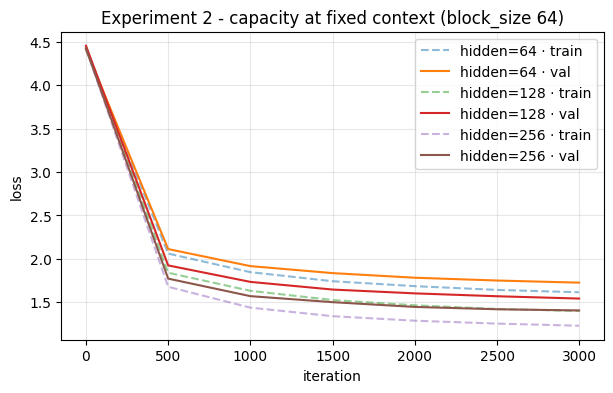

hidden= 64 | params 35,667 | train 1.6143 | val 1.7253 | gap +0.1109 | ppl 5.61
hidden=128 | params 90,515 | train 1.3988 | val 1.5420 | gap +0.1432 | ppl 4.67 | val gain vs previous +0.1833
hidden=256 | params 273,939 | train 1.2289 | val 1.4048 | gap +0.1759 | ppl 4.07 | val gain vs previous +0.1372


In [22]:
plot_histories({'hidden=64': h_h64, 'hidden=128': h_h128, 'hidden=256': h_h256},
               title='Experiment 2 - capacity at fixed context (block_size 64)')

prev = None
for label, hist, n in [('hidden= 64', h_h64, n_h64), ('hidden=128', h_h128, n_h128), ('hidden=256', h_h256, n_h256)]:
    tr, va = hist[-1][1], hist[-1][2]
    gain = '' if prev is None else f' | val gain vs previous {prev - va:+.4f}'
    print(f'{label} | params {n:6,} | train {tr:.4f} | val {va:.4f} | gap {va - tr:+.4f} | ppl {math.exp(va):.2f}{gain}')
    prev = va

In [23]:
# The same robustness check for this experiment: the width comparison at seed 2024,
# 1,500 iterations. The hidden=256 arm at seed 2024 already exists — it is the block_size=64
# run in Experiment 1's replication (val 1.4894 at step 1499) — so only hidden=64 is new.
Pr = build_char_pipeline(text, block_size=64, batch_size=32, device=device)
torch.manual_seed(2024)
mr = MyLanguageModel(Pr['vocab_size'], hidden=64).to(device)
mr, hr = train_model_tracked(mr, Pr['get_batch'], Pr['estimate_loss'],
                             max_iters=1500, eval_interval=500, lr=1e-3, device=device)
print(f"seed 2024 | hidden  64 | final train {hr[-1][1]:.4f} | val {hr[-1][2]:.4f}")
print( "seed 2024 | hidden 256 | final val 1.4894 (Experiment 1 replication, identical settings)")

step     0 | train 4.4281 | val 4.4295


step   500 | train 2.0638 | val 2.1206


step  1000 | train 1.8606 | val 1.9336


step  1499 | train 1.7512 | val 1.8457
seed 2024 | hidden  64 | final train 1.7512 | val 1.8457
seed 2024 | hidden 256 | final val 1.4894 (Experiment 1 replication, identical settings)


**Interpretation.**

Half right, and the half I got wrong is the more interesting one. Validation loss fell monotonically with width {**1.7253** (35,667 parameters), **1.5420** (90,515), **1.4048** (273,939)} and returns did diminish, though less steeply per doubling than I predicted: 64 → 128 bought **0.183** and 128 → 256 bought **0.137**, a ratio of 0.75 rather than the half I guessed. Per parameter the fall is much sharper: 3.3 × 10⁻⁶ of loss per parameter for the first doubling against 0.75 × 10⁻⁶ for the second, and that 4.5-fold drop is what justified stopping at 256 rather than spending my remaining 226,000 parameters. I was plainly wrong about the train/validation gap! I predicted gaps under 0.05 at every width; they were **0.111**, **0.143** and **0.176**, widening monotonically with capacity. The overfitting signature is beginning to appear, even though no validation curve turns up within 3,000 iterations. The 6,889-parameter bigram's **0.040** gap on the same positional split suggests the split itself contributes part of the difference (validation is the final 209,181 characters, later sitting days with different business) so the 0.176 should not be read as pure memorisation (though I cannot cleanly separate the two). The seed-2024 replication at 1,500 iterations reproduces the ordering and the rough size of the width effect (**1.8457** against **1.4894**). The caveats are one seed pair, one corpus and a fixed 3,000-iteration budget, so I'll interpret this as diminishing returns *at this budget* and not an asymptotic claim about width.

## 5 · Discussion

### Diagnosis: underfitting, overfitting, or about right?

About right, and if anything still underfitting. The final model reports train **1.1961** and validation **1.3749**, perplexity **4.0** against the bigram's **11.5**. And validation was still falling at the end of training from 1.3963 → 1.3688 over the final 800 iterations, roughly 0.014 per 400 even as the rate decays. I cannot justify early stopping because the curve has not turned. The 0.18 gap, thirty times the 0.006 evaluation spread, so real.. looks like the beginning of overfitting. And Experiment 2 shows it growing with capacity (0.111 → 0.143 → 0.176), but two of my own numbers (bigram and the split) say part of it is not memorisation. The bigram, with 6,889 parameters, shows a 0.040 gap on the same split, and the split is positional so validation is a later stretch of Hansard with different business in it. My honest interpretation is a model fitting the training distribution a little faster than it generalises across sitting days but not yet paying for it.

Instead of building a bigger one, with ten times the compute I would train this same architecture roughly ten times longer with a decaying learning rate. Iterations are the binding constraint, at roughly 0.014 per 400, a tenfold budget has room to spend before the curve flattens even allowing for the deceleration. Capacity is not, as the last doubling of width bought only 0.137 for 183,000 parameters, and the rules cap me at 500,000 anyway. I would add dropout only if the validation curve turned.

### What the model learned, and what it consistently gets wrong

What the model has learned is the *shape* of Hansard. Every sample reproduces the corpus format unprompted, a capitalised two-part name, a colon, a newline, then a turn, "Grevieve Reed:\nI have increding it to the victims of nature". Given "The Prime Minister:", it answers in the register of Question Time, "Can the Member for … our questions?", then hands the floor to a fresh header, "Marpabour Nagelan:". The register is right but at quite a short range: quoted speech, and question marks on interrogative turns.

It goes wrong with anything longer than a clause though. Names are plausible letter sequences and not real MPs ("Grevieve Reed", "Scutelocker"), words drift into near-words ("afternoties", "recognife", "forwgastive"), punctuation goes unmatched, as in the stray closing bracket in "responsib)", and no sentence holds one subject: "it met the some six is not been story with the control". The most obvious failure is in the prompted sample, where a backbencher's question comes out of the Prime Minister's mouth so the header format is learned and the constraint it places on the turn is not. A character-level model with a fading hidden state makes little use of context beyond thirty characters, and my per-position curve is flat past position 32, hence dependencies spanning the speaker header and the later turn appear difficult for the model to exploit. Next-character training also optimises plausibility and not truth so nothing rewards a name that exists or a role played correctly.

### The data: legitimacy and the concern that survives it

Training on Hansard is legitimate because it is the official record of elected representatives speaking in their public capacity, published so that their words can be read, quoted and reused. The Open Parliament Licence v3.0 states that it permits copying, adaptation and derivative works, which is what training is. The two questions that make scraping contentious, permission and expectation, are both settled here. The licence grants the first and publicity is the constitutional point of the record so the training violates no expectation an MP could reasonably hold about words spoken in the Chamber.

The concern that survives even this clean case is fabricated attribution. Scraped text binds words to named identities (bylines, handles, speaker headers) and a generative model learns the binding along with the prose. Trained on 2,091,809 characters from five sitting days, mine already emits fluent-looking interventions under speaker headers it invents, and prompted with "The Prime Minister:" it will continue in that voice of sentences no one spoke, formatted as though they had. At my scale the output is obvious nonsense; the failure mode isn't however. The same property in a stronger model yields plausible speech under real names, and no licence term addresses it because the harm is not copying what someone said but inventing what they did not.